In [1]:
# Conexión a la base de datos utilizando SQLAlchemy y psycopg2
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()

DB_CONFIG = {
    "host": os.getenv("DB_HOST"),
    "port": os.getenv("DB_PORT"),
    "dbname": os.getenv("DB_NAME"),
    "user": os.getenv("DB_USER"),
    "password": os.getenv("DB_PASSWORD")
}

def get_engine():
    return create_engine(
        f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
        f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['dbname']}"
    )

engine = get_engine()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_sql("SELECT * FROM hospital_performance_final", engine)

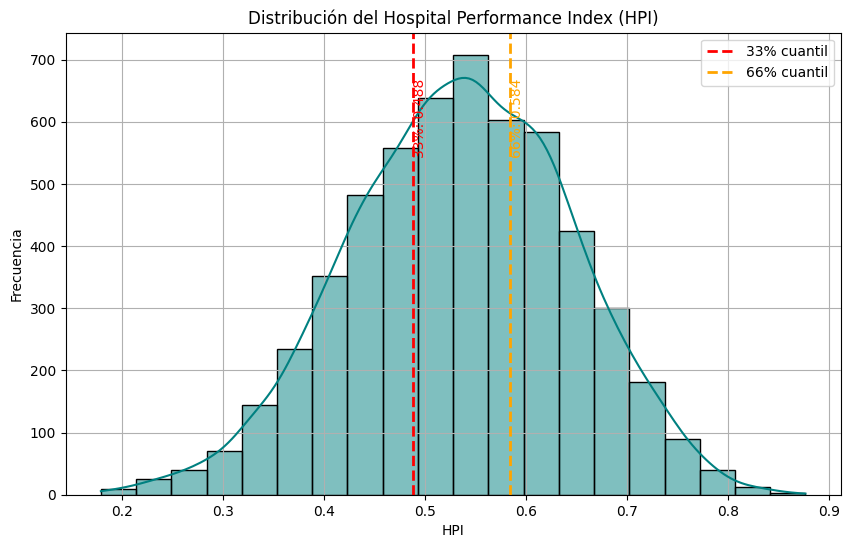

In [6]:
# Histograma del HPI
plt.figure(figsize=(10, 6))
sns.histplot(df['hpi'], bins=20, kde=True, color='teal')
q33, q66 = df['hpi'].quantile([0.33, 0.66])

plt.axvline(q33, color='red', linestyle='--', linewidth=2, label='33% cuantil')
plt.axvline(q66, color='orange', linestyle='--', linewidth=2, label='66% cuantil')

ymax = plt.gca().get_ylim()[1]
plt.text(q33, ymax*0.9, f'33%: {q33:.3f}', color='red', rotation=90, va='top')
plt.text(q66, ymax*0.9, f'66%: {q66:.3f}', color='orange', rotation=90, va='top')

plt.legend()
plt.title('Distribución del Hospital Performance Index (HPI)')
plt.xlabel('HPI')
plt.ylabel('Frecuencia')
plt.grid()
plt.show()

In [8]:
# Segmentación del hpi en 3 categorías (terciles)
df["hpi_class"] = pd.qcut(
    df["hpi"],
    q=3,
    labels=["low", "medium", "high"]
)

In [10]:
hpi_bajo = df[df['hpi_class']=='low'].copy()
hpi_medio = df[df['hpi_class']=='medium'].copy()
hpi_alto = df[df['hpi_class']=='high'].copy()

In [13]:
# Configuración que permite mostrar todas las columnas
pd.set_option('display.max_columns', None)

In [14]:
hpi_bajo.describe()

,year,total_beds,icu_beds,operation_theatres,medical_equipment_score,total_doctors,specialists,nurses,paramedical_staff,doctor_patient_ratio,daily_outpatients,monthly_admissions,surgeries_per_month,average_length_of_stay,emergency_cases,average_treatment_cost,consultation_fee,surgery_cost,government_funding,patient_satisfaction_score,mortality_rate,infection_rate,readmission_rate,waiting_time_minutes,distance_from_city_center,rural_patients_percentage,estimated_daily_load,icu_inconsistency_flag,icu_bed_ratio,doctor_per_patient_ratio,surgeries_per_theatre,total_staff,staff_per_patient_ratio,quality_score,efficiency_score,cost_score,hpi
count,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1.833000e+03,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000
mean,2023.030551,769.582651,102.346972,10.660120,6.515985,207.595745,77.435897,402.935625,155.006547,0.001246,1561.880524,756.329514,202.531369,6.783033,411.403164,24632.453355,2018.869067,120977.522095,7.690577e+06,6.804146,3.255423,4.488642,6.335161,114.573377,20.069995,42.652482,1587.091508,0.044190,0.245359,0.259793,34.149631,765.537916,0.939576,0.395547,0.376170,0.512274,0.413076
std,0.822808,421.449990,57.160949,5.744527,1.444781,113.252224,43.042877,225.533243,83.696080,0.000436,848.413966,422.610920,113.338473,2.287469,228.828821,15151.253640,1516.017900,86641.455317,1.373984e+07,1.217819,1.213307,1.741137,2.480940,46.232080,11.355883,21.686528,848.827613,0.205573,0.355976,0.455680,48.039834,266.147901,1.472276,0.121418,0.181861,0.306241,0.059671
min,2022.000000,52.000000,5.000000,1.000000,4.000000,10.000000,5.000000,20.000000,10.000000,0.000501,51.000000,21.000000,5.000000,1.500000,10.000000,509.000000,100.000000,5065.000000,0.000000e+00,5.000000,0.510000,0.510000,1.000000,5.000000,1.000000,5.000000,54.333333,0.000000,0.003340,0.003287,0.388889,82.000000,0.036312,0.069000,0.003000,0.000000,0.179000
25%,2022.000000,401.000000,52.000000,6.000000,5.300000,110.000000,39.000000,210.000000,80.000000,0.000866,851.000000,408.000000,106.000000,5.000000,213.000000,11004.000000,604.000000,47080.000000,0.000000e+00,5.800000,2.400000,3.240000,4.410000,81.000000,9.900000,24.000000,867.800000,0.000000,0.068449,0.069201,9.352941,566.000000,0.317084,0.311000,0.234000,0.227000,0.381000
50%,2023.000000,768.000000,104.000000,11.000000,6.500000,209.000000,77.000000,402.000000,154.000000,0.001249,1591.000000,737.000000,202.000000,7.200000,414.000000,23822.000000,1705.000000,90420.000000,0.000000e+00,6.600000,3.450000,4.770000,6.710000,122.000000,20.000000,43.000000,1618.433333,0.000000,0.129870,0.131864,18.937500,768.000000,0.476712,0.392000,0.372000,0.529000,0.426000
75%,2024.000000,1129.000000,151.000000,16.000000,7.700000,304.000000,115.000000,596.000000,228.000000,0.001628,2274.000000,1130.000000,304.000000,8.800000,610.000000,38740.000000,3359.000000,194281.000000,1.081586e+07,7.700000,4.290000,5.950000,8.480000,154.000000,30.000000,61.000000,2300.000000,0.000000,0.254386,0.243698,36.700000,961.000000,0.888830,0.475000,0.507000,0.788000,0.459000
max,2024.000000,1500.000000,200.000000,20.000000,9.000000,400.000000,150.000000,800.000000,300.000000,0.002000,3000.000000,1500.000000,400.000000,10.000000,800.000000,49977.000000,4990.000000,299953.000000,4.990293e+07,9.500000,5.000000,6.990000,10.000000,180.000000,40.000000,80.000000,3042.900000,1.000000,3.316667,5.705128,391.000000,1448.000000,15.773006,0.812000,0.937000,1.000000,0.488000


In [15]:
hpi_medio.describe()

,year,total_beds,icu_beds,operation_theatres,medical_equipment_score,total_doctors,specialists,nurses,paramedical_staff,doctor_patient_ratio,daily_outpatients,monthly_admissions,surgeries_per_month,average_length_of_stay,emergency_cases,average_treatment_cost,consultation_fee,surgery_cost,government_funding,patient_satisfaction_score,mortality_rate,infection_rate,readmission_rate,waiting_time_minutes,distance_from_city_center,rural_patients_percentage,estimated_daily_load,icu_inconsistency_flag,icu_bed_ratio,doctor_per_patient_ratio,surgeries_per_theatre,total_staff,staff_per_patient_ratio,quality_score,efficiency_score,cost_score,hpi
count,1837.000000,1837.000000,1837.000000,1837.000000,1837.000000,1837.000000,1837.000000,1837.000000,1837.000000,1837.000000,1837.000000,1837.000000,1837.000000,1837.000000,1837.000000,1837.000000,1837.000000,1837.000000,1.837000e+03,1837.000000,1837.00000,1837.000000,1837.000000,1837.00000,1837.000000,1837.000000,1837.000000,1837.000000,1837.000000,1837.000000,1837.000000,1837.000000,1837.000000,1837.000000,1837.000000,1837.000000,1837.000000
mean,2022.955362,774.022863,104.497550,10.494284,6.532608,204.156233,78.005444,408.630920,151.371257,0.001244,1450.197605,745.831791,205.266195,5.781764,403.994556,15692.032662,1582.814371,100910.353838,1.299879e+07,7.299946,2.75478,3.825329,5.495444,93.51497,21.082744,43.406097,1475.058664,0.040283,0.246171,0.271587,37.103494,764.158410,1.043659,0.499739,0.495246,0.692988,0.537037
std,0.815275,421.008055,57.244351,5.725911,1.420948,111.917201,41.440195,222.795951,85.409978,0.000435,847.165466,426.968142,113.634267,2.369169,226.953411,12314.295352,1490.528219,83196.782039,1.633369e+07,1.264396,1.28985,1.849503,2.566361,48.83621,11.142195,21.799056,847.053244,0.196676,0.349265,0.435170,56.296728,264.748721,1.561995,0.113875,0.176654,0.248906,0.027847
min,2022.000000,50.000000,5.000000,1.000000,4.000000,10.000000,5.000000,20.000000,10.000000,0.000501,50.000000,21.000000,5.000000,1.500000,10.000000,519.000000,100.000000,5052.000000,0.000000e+00,5.000000,0.51000,0.500000,1.010000,5.00000,1.000000,5.000000,57.400000,0.000000,0.003613,0.003707,0.263158,141.000000,0.072488,0.131000,0.044000,0.003000,0.489000
25%,2022.000000,409.000000,57.000000,6.000000,5.400000,109.000000,42.000000,223.000000,77.000000,0.000872,714.000000,376.000000,111.000000,3.800000,213.000000,6741.000000,439.000000,39307.000000,0.000000e+00,6.200000,1.65000,2.240000,3.330000,53.00000,11.400000,25.000000,739.833333,0.000000,0.070644,0.071795,9.950000,567.000000,0.331300,0.425000,0.369000,0.542000,0.513000
50%,2023.000000,775.000000,105.000000,10.000000,6.500000,201.000000,79.000000,402.000000,151.000000,0.001229,1408.000000,743.000000,207.000000,5.800000,400.000000,11705.000000,739.000000,68414.000000,2.393592e+06,7.300000,2.77000,3.870000,5.490000,94.00000,21.800000,43.000000,1430.133333,0.000000,0.135593,0.138895,19.500000,767.000000,0.514408,0.494000,0.497000,0.774000,0.537000
75%,2024.000000,1136.000000,155.000000,15.000000,7.700000,301.000000,114.000000,603.000000,225.000000,0.001632,2189.000000,1112.000000,306.000000,7.800000,596.000000,23169.000000,2749.000000,153171.000000,2.550550e+07,8.400000,3.87000,5.410000,7.680000,134.00000,30.600000,62.000000,2215.266667,0.000000,0.258917,0.274549,36.333333,966.000000,1.046915,0.577000,0.618000,0.874000,0.560000
max,2024.000000,1500.000000,200.000000,20.000000,9.000000,400.000000,150.000000,800.000000,300.000000,0.002000,2999.000000,1498.000000,400.000000,10.000000,800.000000,49825.000000,4993.000000,299865.000000,4.996937e+07,9.500000,5.00000,7.000000,10.000000,180.00000,40.000000,80.000000,3034.833333,1.000000,3.140000,4.943503,399.000000,1474.000000,19.616725,0.887000,0.994000,1.000000,0.586000


In [16]:
hpi_alto.describe()

,year,total_beds,icu_beds,operation_theatres,medical_equipment_score,total_doctors,specialists,nurses,paramedical_staff,doctor_patient_ratio,daily_outpatients,monthly_admissions,surgeries_per_month,average_length_of_stay,emergency_cases,average_treatment_cost,consultation_fee,surgery_cost,government_funding,patient_satisfaction_score,mortality_rate,infection_rate,readmission_rate,waiting_time_minutes,distance_from_city_center,rural_patients_percentage,estimated_daily_load,icu_inconsistency_flag,icu_bed_ratio,doctor_per_patient_ratio,surgeries_per_theatre,total_staff,staff_per_patient_ratio,quality_score,efficiency_score,cost_score,hpi
count,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.00000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1.830000e+03,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000
mean,2022.994536,790.680874,102.445355,10.529508,6.439016,200.614754,78.797814,410.34918,152.643716,0.001272,1529.015847,763.249180,202.089071,4.564262,409.327322,10359.606557,1172.707650,79572.467213,1.717224e+07,7.806831,2.274885,3.095902,4.555410,70.693989,20.265027,42.560656,1554.457486,0.038798,0.235666,0.253577,36.570989,763.607650,0.979288,0.608730,0.632059,0.800766,0.654125
std,0.826021,422.771740,56.429134,5.826633,1.438610,114.575899,42.125325,230.68572,85.082495,0.000429,837.644274,428.297354,117.072511,2.252262,230.736296,8552.412886,1303.108246,71387.474859,1.657362e+07,1.209061,1.242152,1.789766,2.474795,46.428888,11.454215,21.826053,837.513155,0.193166,0.354602,0.442609,54.242589,265.932253,1.584348,0.117213,0.176841,0.172873,0.051962
min,2022.000000,51.000000,5.000000,1.000000,4.000000,10.000000,5.000000,20.00000,10.000000,0.000500,50.000000,20.000000,5.000000,1.500000,10.000000,502.000000,100.000000,5068.000000,0.000000e+00,5.000000,0.500000,0.500000,1.000000,5.000000,1.000000,5.000000,57.966667,0.000000,0.004216,0.004105,0.350000,116.000000,0.048971,0.263000,0.044000,0.003000,0.587000
25%,2022.000000,412.000000,53.000000,5.000000,5.200000,99.000000,42.000000,211.25000,79.000000,0.000912,826.750000,398.000000,97.000000,2.600000,207.000000,4469.750000,349.000000,32406.500000,0.000000e+00,6.900000,1.182500,1.570000,2.430000,32.000000,9.700000,24.000000,854.566667,0.000000,0.068107,0.065025,9.000000,561.250000,0.323148,0.528000,0.508000,0.744250,0.613000
50%,2023.000000,800.000000,103.000000,10.000000,6.400000,200.500000,78.000000,409.50000,151.000000,0.001293,1547.500000,763.500000,205.500000,4.100000,413.000000,8486.000000,602.000000,55813.000000,1.345646e+07,8.000000,2.110000,2.810000,4.220000,63.000000,20.450000,42.500000,1574.550000,0.000000,0.128566,0.126030,19.111111,760.000000,0.493816,0.610000,0.642000,0.839000,0.642000
75%,2024.000000,1169.750000,151.000000,16.000000,7.700000,300.000000,115.750000,610.00000,227.000000,0.001641,2232.750000,1137.250000,306.000000,6.200000,613.750000,13145.250000,1465.000000,82452.500000,3.178843e+07,8.800000,3.190000,4.470000,6.460000,105.000000,30.100000,62.000000,2254.458333,0.000000,0.239222,0.250200,38.125000,971.500000,0.902836,0.687000,0.768000,0.920000,0.686000
max,2024.000000,1499.000000,200.000000,20.000000,9.000000,400.000000,150.000000,800.00000,300.000000,0.001999,2995.000000,1500.000000,400.000000,10.000000,800.000000,49812.000000,4995.000000,299853.000000,4.998359e+07,9.500000,5.000000,6.990000,9.980000,180.000000,40.000000,80.000000,3026.466667,1.000000,3.462963,5.382404,395.000000,1416.000000,15.748473,0.954000,0.997000,1.000000,0.877000


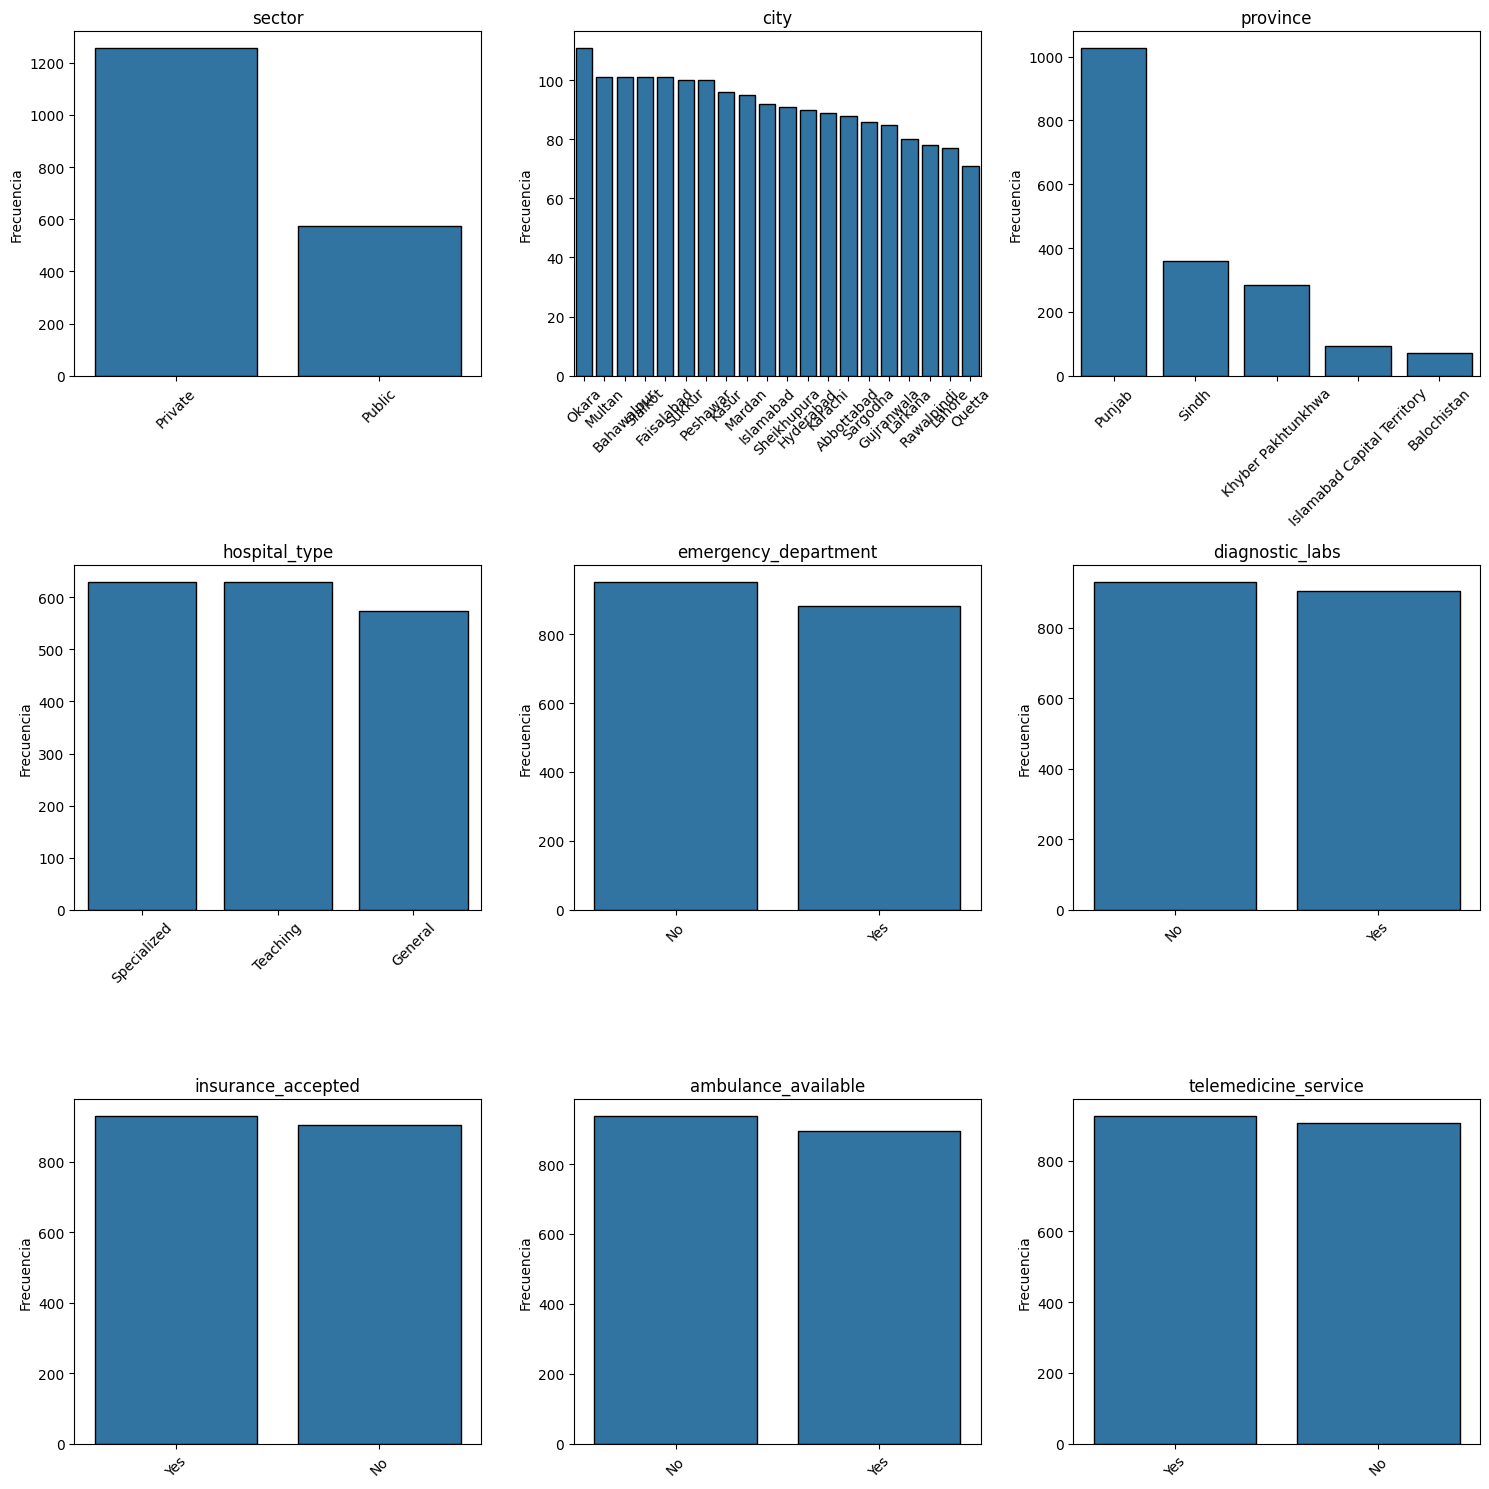

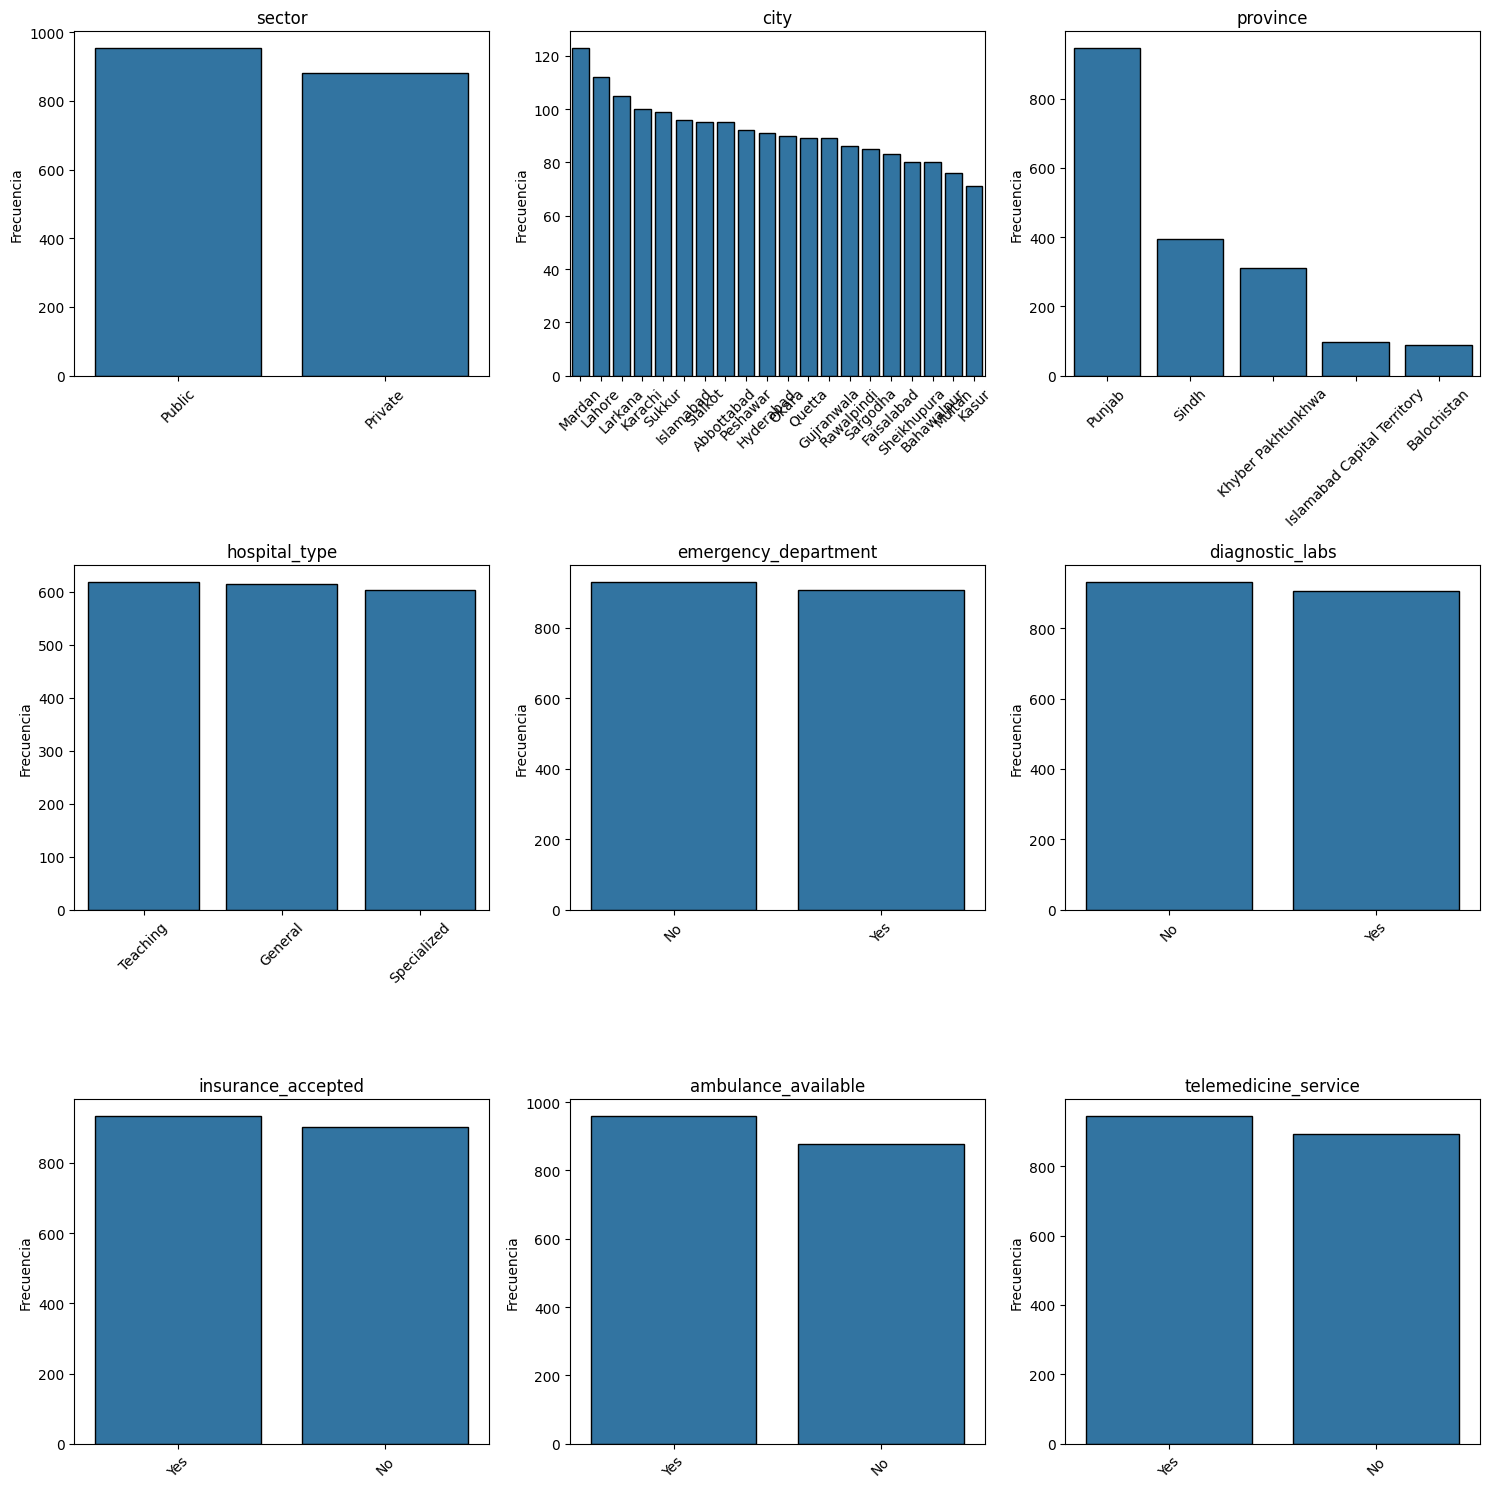

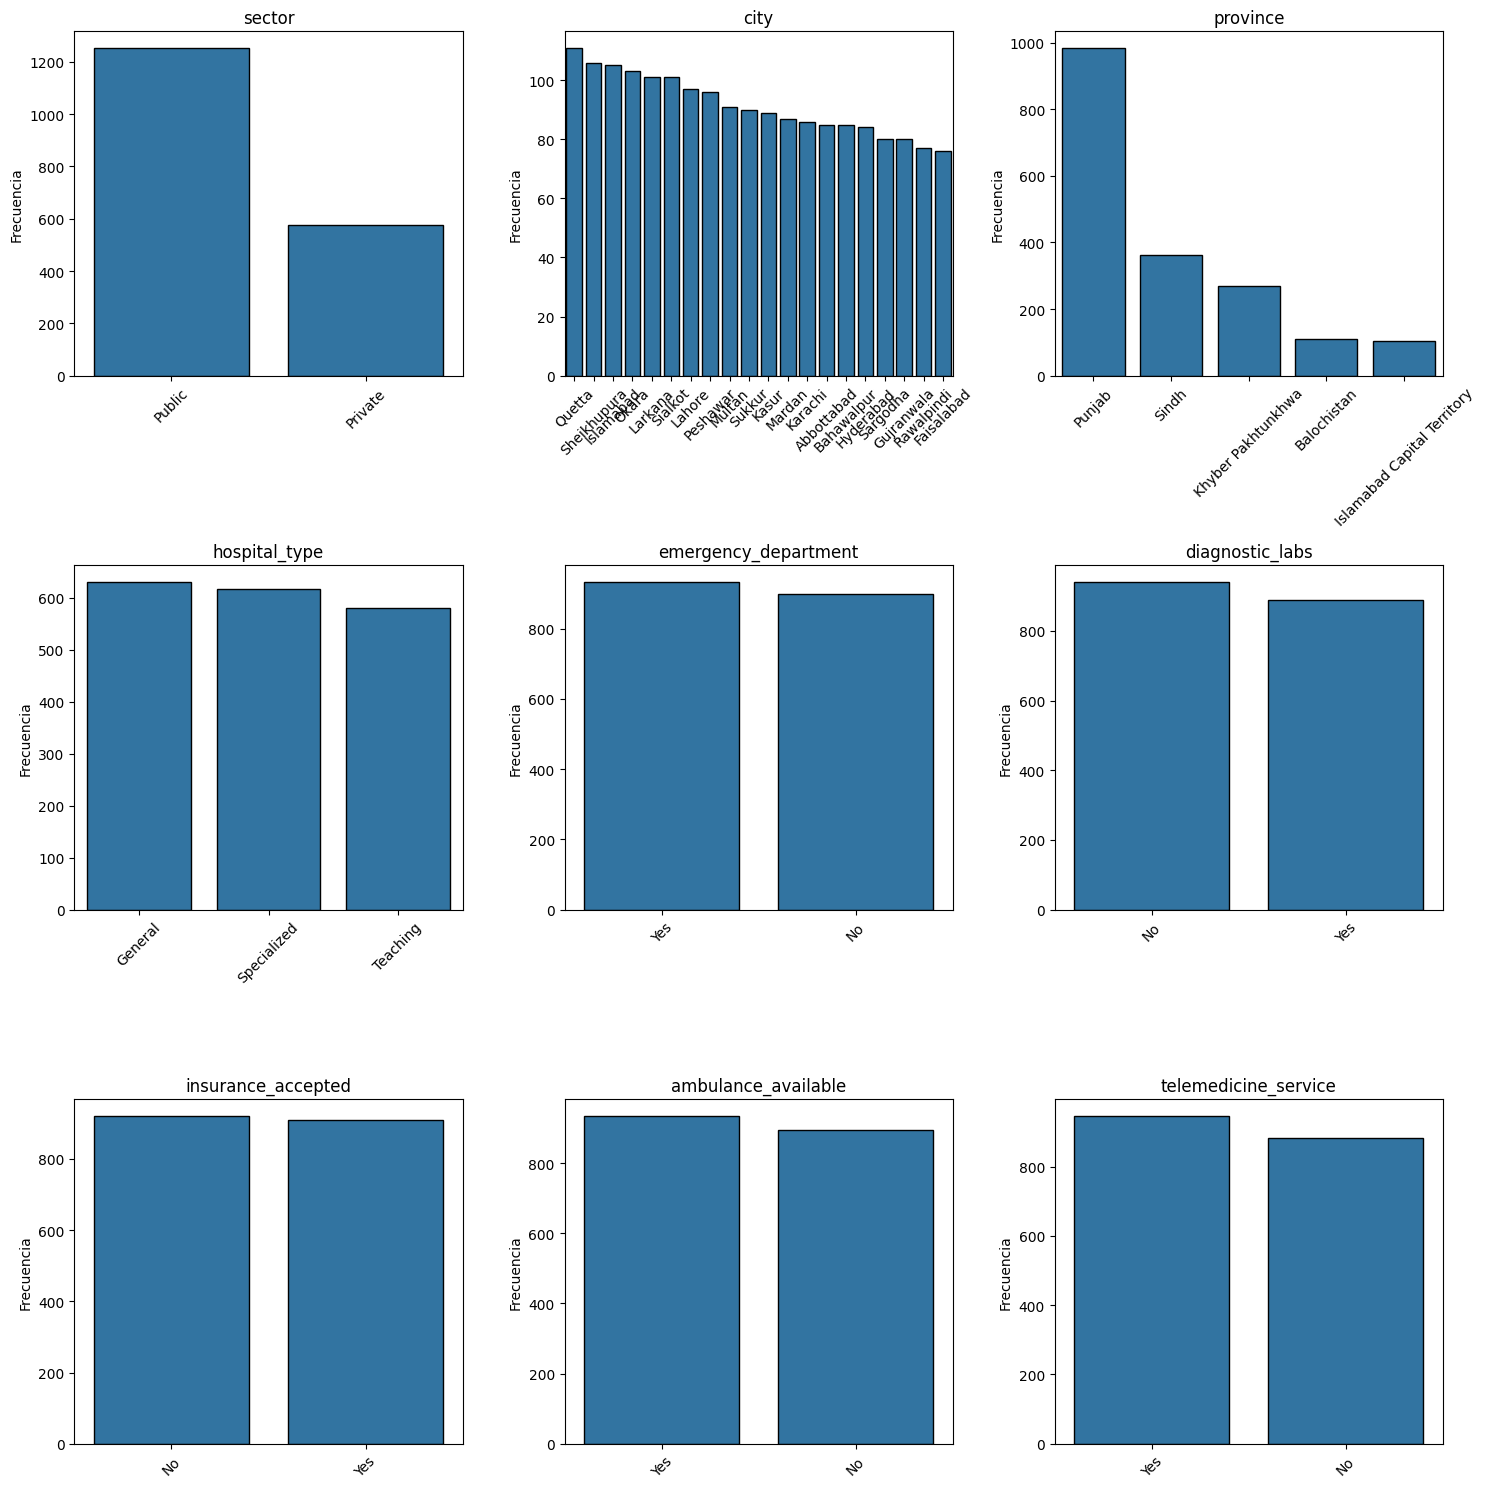

In [17]:
import math

# seleccionar variables categóricas
cat_cols = [
    col for col in df.select_dtypes(include=["object"]).columns
    if df[col].nunique() < 30  # filtro recomendable
]

n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

for df in [hpi_bajo, hpi_medio, hpi_alto]:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()  # simplifica indexado

    for i, col in enumerate(cat_cols):
        ax = axes[i]

        value_counts = df[col].value_counts()

        sns.barplot(x=value_counts.index, y=value_counts.values, edgecolor="black", ax=ax)

        ax.set_title(col)
        ax.set_xlabel("")
        ax.set_ylabel("Frecuencia")
        ax.tick_params(axis="x", rotation=45)

    # eliminar ejes vacíos (si sobran)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()